In [7]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [8]:
# load dataset
HIV_df = pd.read_csv('HIV data 2000-2023.csv', encoding='latin1')
HIV_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000]
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000]
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000]
3,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2020,320 000 [280 000 - 370 000]
4,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2015,300 000 [260 000 - 350 000]


In [9]:
# explore dataset
print(HIV_df.shape)
print(HIV_df.info())

(1552, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   IndicatorCode        1552 non-null   object
 1   Indicator            1552 non-null   object
 2   ValueType            1552 non-null   object
 3   ParentLocationCode   1552 non-null   object
 4   ParentLocation       1552 non-null   object
 5   Location type        1552 non-null   object
 6   SpatialDimValueCode  1552 non-null   object
 7   Location             1552 non-null   object
 8   Period type          1552 non-null   object
 9   Period               1552 non-null   int64 
 10  Value                1552 non-null   object
dtypes: int64(1), object(10)
memory usage: 133.5+ KB
None


In [10]:
# summary stats
HIV_df.describe()

,Period
count,1552.000000
mean,2014.500000
std,8.080351
min,2000.000000
25%,2008.750000
50%,2017.500000
75%,2021.250000
max,2023.000000


In [11]:
# check missing values
HIV_df.isnull().sum()

IndicatorCode          0
Indicator              0
ValueType              0
ParentLocationCode     0
ParentLocation         0
Location type          0
SpatialDimValueCode    0
Location               0
Period type            0
Period                 0
Value                  0
dtype: int64

In [16]:
# extract pont estimate 
def parse_value(v):
    if pd.isna(v) or v == 'No data':
        return None
    point = str(v).split('[')[0].strip()
    point = point.replace('<', '').replace(' ', '').replace('\u00a0', '')
    try:
        return float(point)
    except ValueError:
        return None

HIV_df['n_hiv'] = HIV_df['Value'].apply(parse_value)

In [18]:
# Identify countries contibuting 75% of global burden
latest = HIV_df[HIV_df['Period'] == 2023].dropna(subset=['n_hiv']).sort_values('n_hiv', ascending=False).copy()
latest['cum_share'] = latest['n_hiv'].cumsum() / latest['n_hiv'].sum()

n_needed = (latest['cum_share'] <= 0.75).sum() + 1
top_countries = latest.head(n_needed)['Location'].tolist()

print(f"{n_needed} countries contribute to 75% of the global HIV burden in 2023:")
latest.head(n_needed)[['Location', 'ParentLocationCode', 'n_hiv', 'cum_share']]

14 countries contribute to 75% of the global HIV burden in 2023:


,Location,ParentLocationCode,n_hiv,cum_share
352,South Africa,AFR,7700000.0,0.226911
1272,India,SEAR,2500000.0,0.300584
208,Mozambique,AFR,2400000.0,0.371309
256,Nigeria,AFR,2000000.0,0.430247
336,United Republic of Tanzania,AFR,1700000.0,0.480344
344,Uganda,AFR,1500000.0,0.524548
168,Kenya,AFR,1400000.0,0.565804
360,Zambia,AFR,1300000.0,0.604114
368,Zimbabwe,AFR,1300000.0,0.642424
416,Brazil,AMR,1000000.0,0.671893


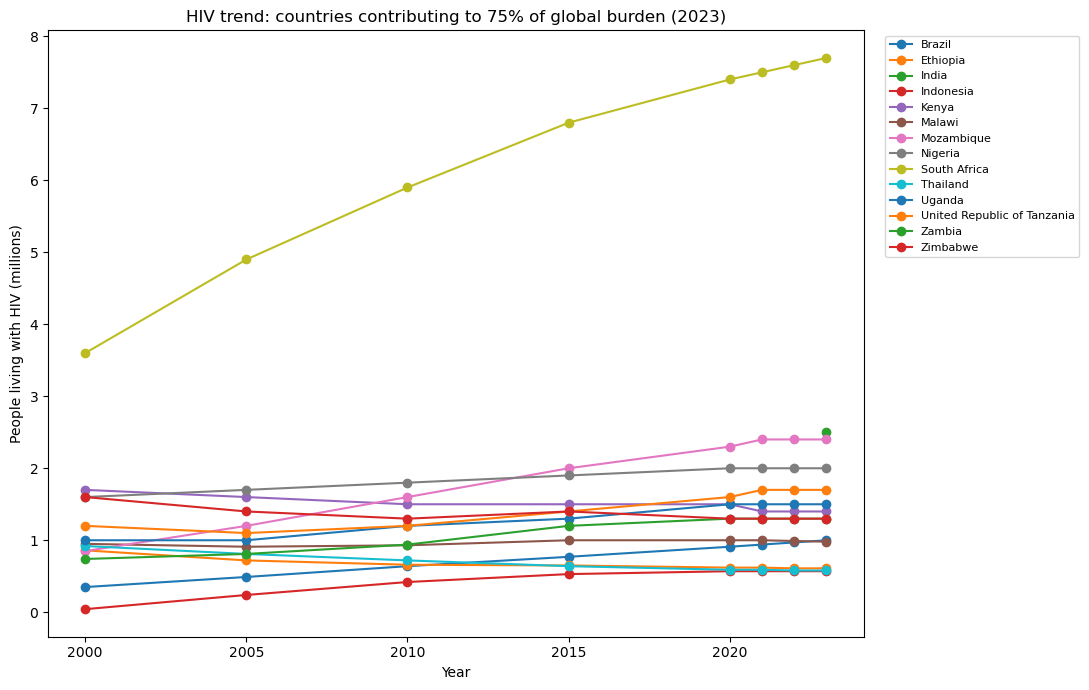

In [20]:
trend = HIV_df[HIV_df['Location'].isin(top_countries)].dropna(subset=['n_hiv'])

plt.figure(figsize=(11, 7))
for country, g in trend.groupby('Location'):
    g = g.sort_values('Period')
    plt.plot(g['Period'], g['n_hiv'] / 1e6, marker='o', label=country)
plt.xlabel('Year')
plt.ylabel('People living with HIV (millions)')
plt.title('HIV trend: countries contributing to 75% of global burden (2023)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [22]:
# WHO regions contributing to 75% of the region's burden
region_top = {}
for region, g in latest.groupby('ParentLocationCode'):
    g = g.sort_values('n_hiv', ascending=False).copy()
    g['cum_share'] = g['n_hiv'].cumsum() / g['n_hiv'].sum()
    n_needed_r = (g['cum_share'] <= 0.75).sum() + 1
    region_top[region] = g.head(n_needed_r)['Location'].tolist()
    print(f"{region}: {n_needed_r} countries -> {region_top[region]}")

AFR: 8 countries -> ['South Africa', 'Mozambique', 'Nigeria', 'United Republic of Tanzania', 'Uganda', 'Kenya', 'Zambia', 'Zimbabwe']
AMR: 6 countries -> ['Brazil', 'Mexico', 'Colombia', 'Argentina', 'Haiti', 'Peru']
EMR: 4 countries -> ['Pakistan', 'Sudan', 'Iran (Islamic Republic of)', 'Egypt']
EUR: 6 countries -> ['France', 'Spain', 'Italy', 'Uzbekistan', 'Portugal', 'Kazakhstan']
SEAR: 2 countries -> ['India', 'Thailand']
WPR: 4 countries -> ['Viet Nam', 'Philippines', 'Malaysia', 'Papua New Guinea']


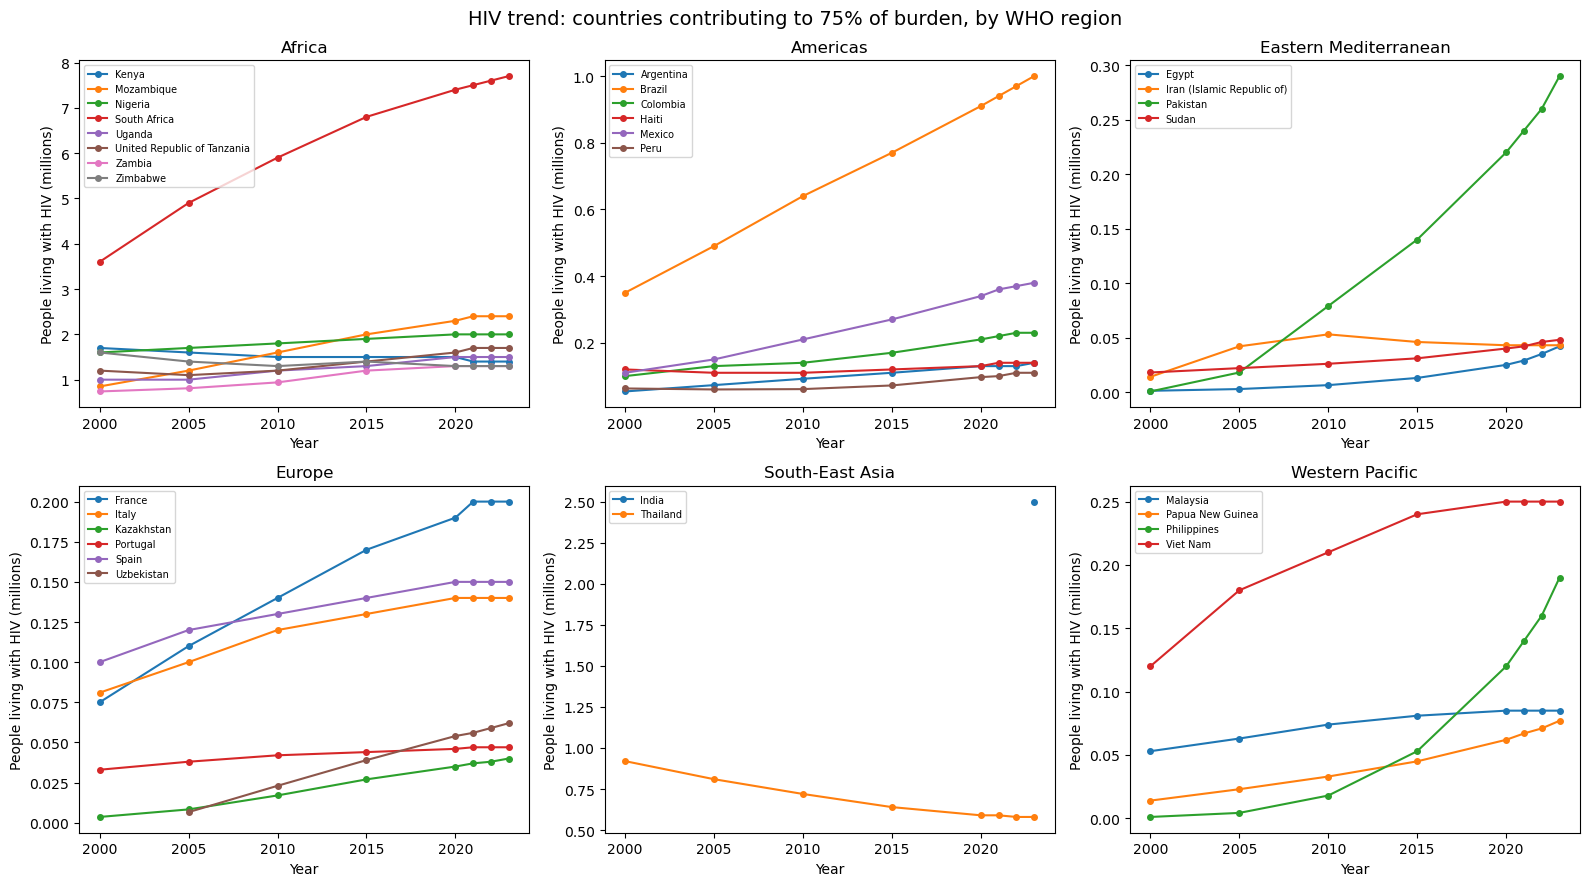

In [24]:
region_names = {'AFR':'Africa','AMR':'Americas','EMR':'Eastern Mediterranean',
                'EUR':'Europe','SEAR':'South-East Asia','WPR':'Western Pacific'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, (region, countries) in zip(axes, region_top.items()):
    sub = HIV_df[HIV_df['Location'].isin(countries)].dropna(subset=['n_hiv'])
    for country, g in sub.groupby('Location'):
        g = g.sort_values('Period')
        ax.plot(g['Period'], g['n_hiv'] / 1e6, marker='o', markersize=4, label=country)
    ax.set_title(region_names.get(region, region))
    ax.set_xlabel('Year')
    ax.set_ylabel('People living with HIV (millions)')
    ax.legend(fontsize=7, loc='upper left')
plt.suptitle('HIV trend: countries contributing to 75% of burden, by WHO region', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# world bank poverty data
raw = pd.read_excel('multidimensional_poverty.xlsx', header=None)
raw.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Individuals in households deprived in each ind...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Region,Country code,Economy,Reporting year,Survey name,Survey year,Survey coverage,Welfare type,Survey comparability,Deprivation rate (share of population),NaN,NaN,NaN,NaN,NaN,Multidimensional poverty headcount ratio (%)
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monetary (%),Educational attainment (%),Educational enrollment (%),Electricity (%),Sanitation (%),Drinking water (%),NaN
3,SSA,AGO,Angola,2018,IDREA,2018,N,c,2,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606
4,ECA,ALB,Albania,2012,HBS,2018,N,c,1,0.048107,0.19238,-,0.06025,6.579772,9.594966,0.293161


In [26]:
# check missing values
raw.isnull().sum()

0     1
1     2
2     2
3     2
4     2
5     2
6     2
7     2
8     2
9     1
10    2
11    2
12    2
13    2
14    2
15    2
dtype: int64

In [28]:
cols = raw.iloc[1].tolist()
sub = raw.iloc[2].tolist()
final_cols = [s if pd.notna(s) else c for c, s in zip(cols, sub)]

pov = raw.iloc[3:].copy()
pov.columns = final_cols
pov = pov.reset_index(drop=True)
pov_cols = ['Country code', 'Monetary (%)', 'Educational attainment (%)', 'Educational enrollment (%)',
            'Electricity (%)', 'Sanitation (%)', 'Drinking water (%)',
            'Multidimensional poverty headcount ratio (%)']
pov_sub = pov[pov_cols].copy() # extract columns
for c in pov_cols[1:]:
    pov_sub[c] = pd.to_numeric(pov_sub[c], errors='coerce')

In [30]:
# merge the two datasets
merged = HIV_df.dropna(subset=['n_hiv']).merge(
    pov_sub, left_on='SpatialDimValueCode', right_on='Country code', how='inner')
merged.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Value,n_hiv,Country code,Monetary (%),Educational attainment (%),Educational enrollment (%),Electricity (%),Sanitation (%),Drinking water (%),Multidimensional poverty headcount ratio (%)
0,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2023,320 000 [280 000 - 380 000],320000.0,AGO,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606
1,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2022,320 000 [280 000 - 380 000],320000.0,AGO,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606
2,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2021,320 000 [280 000 - 380 000],320000.0,AGO,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606
3,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2020,320 000 [280 000 - 370 000],320000.0,AGO,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606
4,HIV_0000000001,Estimated number of people (all ages) living w...,numeric,AFR,Africa,Country,AGO,Angola,Year,2015,300 000 [260 000 - 350 000],300000.0,AGO,31.122005,29.753423,27.44306,52.639532,53.637516,32.106507,47.203606


In [33]:
print(f"{merged.shape[0]} rows, {merged['SpatialDimValueCode'].nunique()} countries in the merged panel")

704 rows, 89 countries in the merged panel


In [ ]:
# mixed effect